<a href="https://colab.research.google.com/github/kyungeunvoyage/MotionDualAxisVib/blob/main/VisualizeForceData(G).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import re, io, textwrap, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [48]:
raw = """
### Fixed-Frequency Gain Sweep
# freqHz=40.000
# baseGain, measRMS_g, clips_%
09:39:17:678 -> 3.000,1.046833,7.264
09:39:18:715 -> 4.000,1.051015,8.231
09:39:19:687 -> 5.000,1.053832,9.199
09:39:20:692 -> 6.000,1.056825,10.167
09:39:21:678 -> 7.000,1.059394,18.876
09:39:22:695 -> 8.000,1.060413,22.746

### Fixed-Frequency Gain Sweep
# freqHz=10.000
# baseGain, measRMS_g, clips_%
09:39:23:700 -> 3.000,1.036913,7.230
09:39:24:706 -> 4.000,1.035312,8.207
09:39:25:682 -> 5.000,1.036070,9.184
09:39:26:687 -> 6.000,1.036194,10.161
09:39:27:704 -> 7.000,1.036516,18.955
09:39:28:692 -> 8.000,1.036236,22.863
""".strip()

In [49]:
# --- Parse ---
freq = None
rows = []
freq_pat = re.compile(r'#\s*freqHz\s*=\s*([0-9.]+)')
line_pat = re.compile(r'->\s*([0-9.]+)\s*,\s*([0-9.]+)\s*,\s*([0-9.]+)')

for line in raw.splitlines():
    m = freq_pat.search(line)
    if m:
        freq = float(m.group(1))
        continue
    m = line_pat.search(line)
    if m and freq is not None:
        baseGain = float(m.group(1))
        rms_g    = float(m.group(2))
        clips    = float(m.group(3))
        rows.append((freq, baseGain, rms_g, clips))

df = pd.DataFrame(rows, columns=["freqHz", "baseGain", "measRMS_g", "clips_pct"]).sort_values(["freqHz","baseGain"])
display(df)

,freqHz,baseGain,measRMS_g,clips_pct
6,10.0,3.0,1.036913,7.230
7,10.0,4.0,1.035312,8.207
8,10.0,5.0,1.036070,9.184
9,10.0,6.0,1.036194,10.161
10,10.0,7.0,1.036516,18.955
11,10.0,8.0,1.036236,22.863
0,40.0,3.0,1.046833,7.264
1,40.0,4.0,1.051015,8.231
2,40.0,5.0,1.053832,9.199
3,40.0,6.0,1.056825,10.167


In [50]:
# CSV 저장 (원하면 다운로드)
df.to_csv("fixed_freq_gain_sweep.csv", index=False)
print("Saved: fixed_freq_gain_sweep.csv")

Saved: fixed_freq_gain_sweep.csv


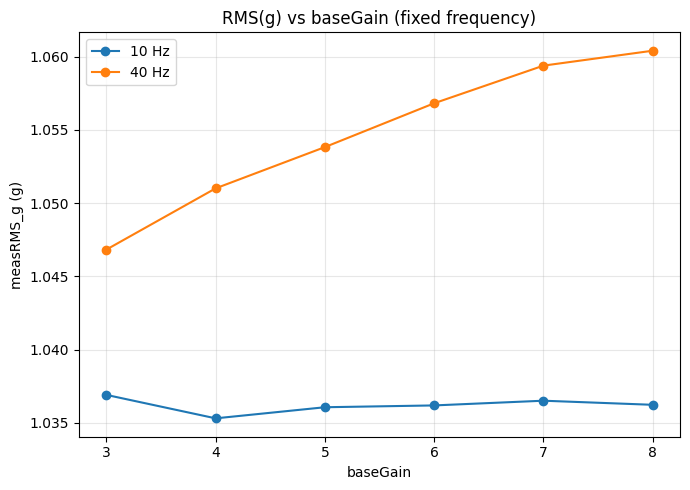

In [51]:
# --- Plot: measRMS_g vs baseGain (두 주파수 한 그래프) ---
plt.figure(figsize=(7,5))
for f, dsub in df.groupby("freqHz"):
    dsub = dsub.sort_values("baseGain")
    plt.plot(dsub["baseGain"].values, dsub["measRMS_g"].values, marker='o', label=f"{f:.0f} Hz")
plt.xlabel("baseGain")
plt.ylabel("measRMS_g (g)")
plt.title("RMS(g) vs baseGain (fixed frequency)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

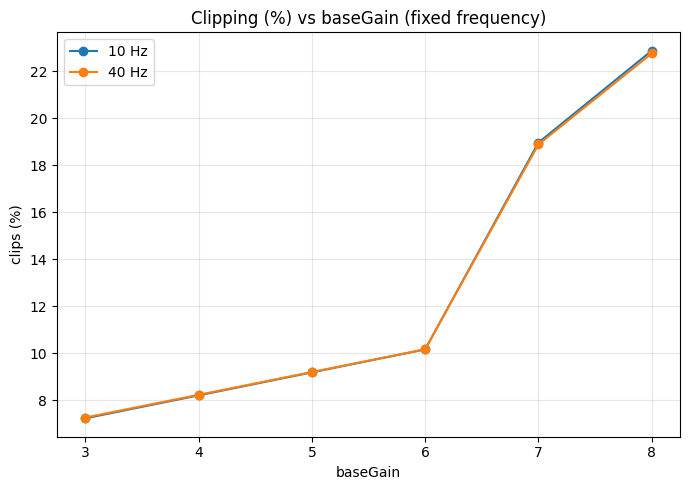

In [52]:
# --- Plot: clips_% vs baseGain (두 주파수 한 그래프) ---
plt.figure(figsize=(7,5))
for f, dsub in df.groupby("freqHz"):
    dsub = dsub.sort_values("baseGain")
    plt.plot(dsub["baseGain"].values, dsub["clips_pct"].values, marker='o', label=f"{f:.0f} Hz")
plt.xlabel("baseGain")
plt.ylabel("clips (%)")
plt.title("Clipping (%) vs baseGain (fixed frequency)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# --- (옵션) 각 주파수마다 별도의 요약 출력 ---
for f, dsub in df.groupby("freqHz"):
    print(f"\n== {f:.0f} Hz ==")
    print("baseGain:", list(dsub['baseGain'].round(3)))
    print("RMS(g):  ", list(dsub['measRMS_g'].round(6)))
    print("clips%:  ", list(dsub['clips_pct'].round(3)))


== 10 Hz ==
baseGain: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
RMS(g):   [1.036913, 1.035312, 1.03607, 1.036194, 1.036516, 1.036236]
clips%:   [7.23, 8.207, 9.184, 10.161, 18.955, 22.863]

== 40 Hz ==
baseGain: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
RMS(g):   [1.046833, 1.051015, 1.053832, 1.056825, 1.059394, 1.060413]
clips%:   [7.264, 8.231, 9.199, 10.167, 18.876, 22.746]


In [54]:
raw_text = """
==== BaseGain Sweep (RAW vs COMP) ====
#MODE,baseG,f_Hz,gainApplied,meas_RMS_g,clips_%
# MODE: RAW(보정없음), COMP(LUT보정사용)
09:45:07:210 -> RAW,3.000000,10.000,3.000000,1.073428,7.230
09:45:08:212 -> COMP,3.000000,10.000,6.946470,1.037332,17.978
09:45:09:186 -> RAW,3.000000,20.000,3.000000,1.038296,7.507
09:45:10:193 -> COMP,3.000000,20.000,6.810329,1.039415,18.255
09:45:11:214 -> RAW,3.000000,30.000,3.000000,1.051392,7.442
09:45:12:190 -> COMP,3.000000,30.000,6.307977,1.065418,10.416
09:45:13:196 -> RAW,3.000000,40.000,3.000000,1.060583,7.264
09:45:14:201 -> COMP,3.000000,40.000,5.847534,1.086571,10.167
09:45:15:206 -> RAW,3.000000,60.000,3.000000,1.059417,7.377
09:45:16:204 -> COMP,3.000000,60.000,5.767317,1.082864,9.344
09:45:17:209 -> RAW,3.000000,80.000,3.000000,1.043240,7.307
09:45:18:214 -> COMP,3.000000,80.000,6.111984,1.051100,10.228
09:45:19:217 -> RAW,4.000000,10.000,4.000000,1.035653,8.207
09:45:20:220 -> COMP,4.000000,10.000,9.261960,1.038161,27.748
09:45:21:197 -> RAW,4.000000,20.000,4.000000,1.037184,8.506
09:45:22:202 -> COMP,4.000000,20.000,9.080440,1.038624,28.004
09:45:23:208 -> RAW,4.000000,30.000,4.000000,1.055389,8.434
09:45:24:196 -> COMP,4.000000,30.000,8.410636,1.066483,25.057
09:45:25:217 -> RAW,4.000000,40.000,4.000000,1.069155,8.231
09:45:26:208 -> COMP,4.000000,40.000,7.796712,1.099377,21.779
09:45:27:196 -> RAW,4.000000,60.000,4.000000,1.069165,8.360
09:45:28:211 -> COMP,4.000000,60.000,7.689756,1.099579,22.067
09:45:29:213 -> RAW,4.000000,80.000,4.000000,1.045957,8.281
09:45:30:221 -> COMP,4.000000,80.000,8.149312,1.056049,23.862
09:45:31:207 -> RAW,5.000000,10.000,5.000000,1.035751,9.184
09:45:32:199 -> COMP,5.000000,10.000,11.577450,1.039475,31.656
09:45:33:214 -> RAW,5.000000,20.000,5.000000,1.037929,9.481
09:45:34:219 -> COMP,5.000000,20.000,11.350550,1.038523,31.903
09:45:35:207 -> RAW,5.000000,30.000,5.000000,1.060425,9.425
09:45:36:225 -> COMP,5.000000,30.000,10.513295,1.063469,29.932
09:45:37:200 -> RAW,5.000000,40.000,5.000000,1.079103,9.199
09:45:38:219 -> COMP,5.000000,40.000,9.745890,1.102936,28.552
09:45:39:209 -> RAW,5.000000,60.000,5.000000,1.077182,9.344
09:45:40:226 -> COMP,5.000000,60.000,9.612195,1.112055,28.916
09:45:41:229 -> RAW,5.000000,80.000,5.000000,1.048839,9.255
09:45:42:216 -> COMP,5.000000,80.000,10.186640,1.059352,28.732
09:45:43:217 -> RAW,6.000000,10.000,6.000000,1.036719,10.161
09:45:44:234 -> COMP,6.000000,10.000,13.892941,1.039694,35.564
09:45:45:219 -> RAW,6.000000,20.000,6.000000,1.039013,10.456
09:45:46:219 -> COMP,6.000000,20.000,13.620659,1.039569,34.828
09:45:47:206 -> RAW,6.000000,30.000,6.000000,1.065683,10.416
09:45:48:208 -> COMP,6.000000,30.000,12.615953,1.060965,32.857
09:45:49:227 -> RAW,6.000000,40.000,6.000000,1.089091,10.167
09:45:50:247 -> COMP,6.000000,40.000,11.695068,1.103530,31.480
09:45:51:217 -> RAW,6.000000,60.000,6.000000,1.086896,10.327
09:45:52:232 -> COMP,6.000000,60.000,11.534634,1.122292,31.849
09:45:53:221 -> RAW,6.000000,80.000,6.000000,1.051064,10.228
09:45:54:210 -> COMP,6.000000,80.000,12.223969,1.062485,32.627
09:45:55:211 -> RAW,7.000000,10.000,7.000000,1.036494,18.955
09:45:56:230 -> COMP,7.000000,10.000,16.208429,1.039542,37.518
09:45:57:247 -> RAW,7.000000,20.000,7.000000,1.038694,19.230
09:45:58:218 -> COMP,7.000000,20.000,15.890769,1.040619,37.753
09:45:59:232 -> RAW,7.000000,30.000,7.000000,1.067431,19.191
09:46:00:217 -> COMP,7.000000,30.000,14.718613,1.059308,35.798
09:46:01:234 -> RAW,7.000000,40.000,7.000000,1.097551,18.876
09:46:02:223 -> COMP,7.000000,40.000,13.644246,1.102616,34.407
09:46:03:244 -> RAW,7.000000,60.000,7.000000,1.096011,19.134
09:46:04:231 -> COMP,7.000000,60.000,13.457073,1.129261,34.782
09:46:05:218 -> RAW,7.000000,80.000,7.000000,1.053436,18.993
09:46:06:223 -> COMP,7.000000,80.000,14.261296,1.065370,35.548
09:46:07:228 -> RAW,8.000000,10.000,8.000000,1.038505,22.863
09:46:08:231 -> COMP,8.000000,10.000,18.523920,1.040608,39.472
09:46:09:235 -> RAW,8.000000,20.000,8.000000,1.038810,23.129
09:46:10:236 -> COMP,8.000000,20.000,18.160879,1.041245,39.703
09:46:11:227 -> RAW,8.000000,30.000,8.000000,1.066885,23.091
09:46:12:234 -> COMP,8.000000,30.000,16.821272,1.058321,38.723
09:46:13:237 -> RAW,8.000000,40.000,8.000000,1.101395,22.746
09:46:14:236 -> COMP,8.000000,40.000,15.593424,1.102074,37.335
09:46:15:237 -> RAW,8.000000,60.000,8.000000,1.103922,23.050
09:46:16:238 -> COMP,8.000000,60.000,15.379512,1.136240,37.715
09:46:17:226 -> RAW,8.000000,80.000,8.000000,1.056355,22.888
09:46:18:243 -> COMP,8.000000,80.000,16.298624,1.066522,37.496
#DONE BaseGainSweep
==== End of BaseGain Sweep ====
"""

In [55]:
# 1) 유니코드 화살표/희한한 공백 normalize (있어도 없어도 OK)
norm = raw_text.replace("→", "->")
# 2) CSV 6필드 패턴을 라인 전체에서 검색 (타임스탬프/문자 앞뒤 상관없이 잡힘)
pat = re.compile(r'(RAW|COMP)\s*,\s*([0-9.]+)\s*,\s*([0-9.]+)\s*,\s*([0-9.]+)\s*,\s*([0-9.]+)\s*,\s*([0-9.]+)')

rows=[]
for line in norm.splitlines():
    m = pat.search(line)
    if not m:
        continue
    mode, baseG, fHz, gainApplied, measRMS, clips = m.groups()
    rows.append({
        "mode": mode,
        "baseG": float(baseG),
        "freqHz": float(fHz),
        "gainApplied": float(gainApplied),
        "meas_RMS_g": float(measRMS),
        "clips_pct": float(clips),
    })

df = pd.DataFrame(rows).sort_values(["freqHz","baseG","mode"]).reset_index(drop=True)

print(f"[DEBUG] parsed rows: {len(df)}")
if df.empty:
    # 문제 원인을 바로 볼 수 있게 앞 10줄을 보조 출력
    print("⚠️ 데이터가 비었습니다. 로그가 제대로 붙었는지 확인하세요. 앞 10줄 미리보기:")
    for i,ln in enumerate(norm.splitlines()[:10]): print(i, repr(ln))


[DEBUG] parsed rows: 72


In [56]:
# 1) 열 정리: 숫자화 + 공백 제거
need_cols = ["mode","baseG","freqHz","gainApplied","meas_RMS_g","clips_pct"]
for c in need_cols:
    if c not in df.columns:
        raise ValueError(f"Column missing: {c}")

df["mode"] = df["mode"].astype(str).str.strip().str.upper()
for c in ["baseG","freqHz","gainApplied","meas_RMS_g","clips_pct"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# NaN 드롭하고 정렬
before = len(df)
df = df.dropna(subset=["mode","baseG","freqHz","meas_RMS_g","clips_pct"]).sort_values(["freqHz","baseG","mode"])
after = len(df)
print(f"[DEBUG] rows: {before} -> {after} after dropna")

print("Unique modes:", df["mode"].unique().tolist())
print("Unique freqs:", sorted(df["freqHz"].unique().tolist()))
print("Unique baseG:", sorted(df["baseG"].unique().tolist()))
print("\nCount table (freq x mode):")
print(df.groupby(["freqHz","mode"]).size().unstack(fill_value=0))

[DEBUG] rows: 72 -> 72 after dropna
Unique modes: ['COMP', 'RAW']
Unique freqs: [10.0, 20.0, 30.0, 40.0, 60.0, 80.0]
Unique baseG: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]

Count table (freq x mode):
mode    COMP  RAW
freqHz           
10.0       6    6
20.0       6    6
30.0       6    6
40.0       6    6
60.0       6    6
80.0       6    6


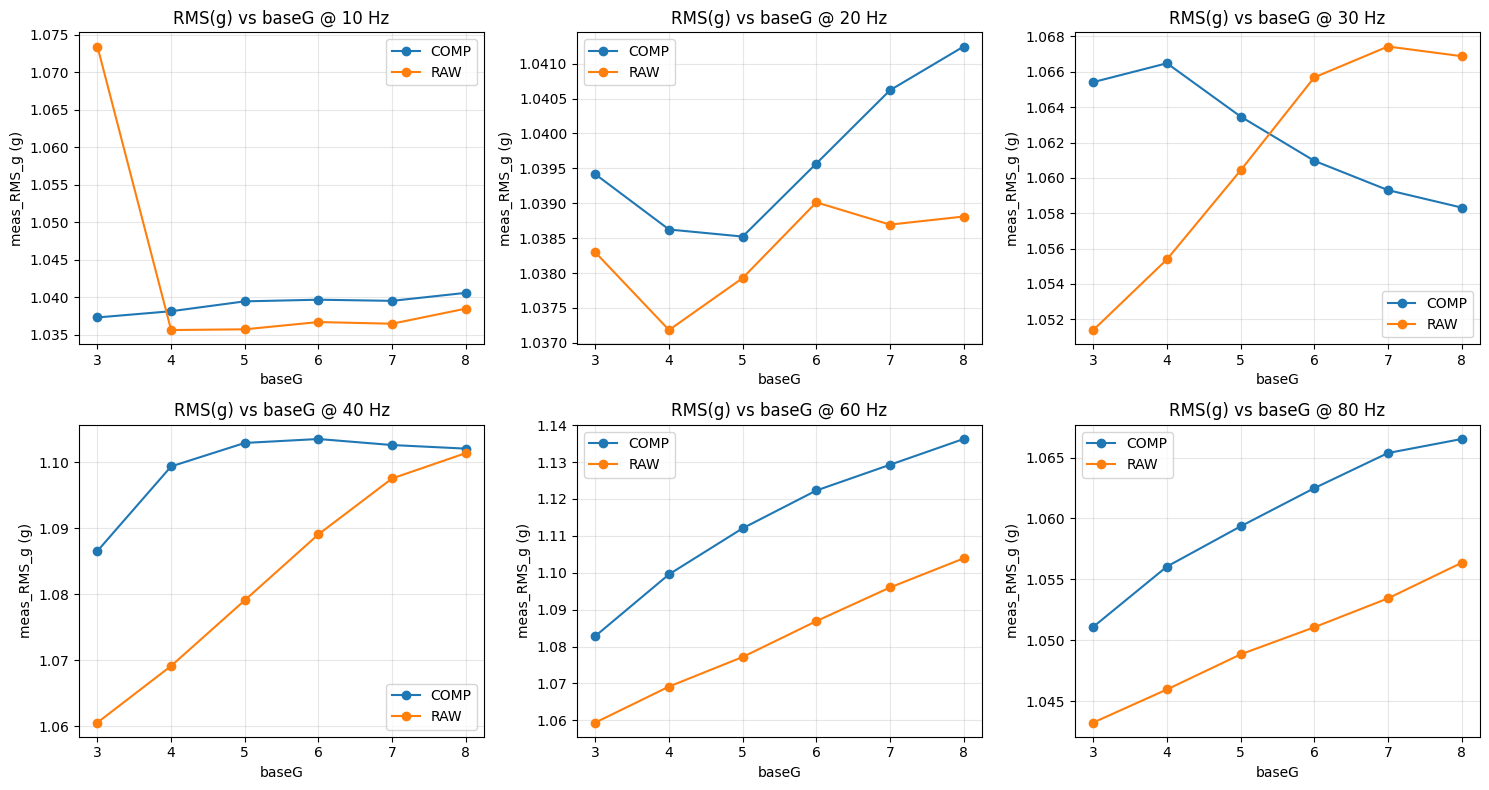

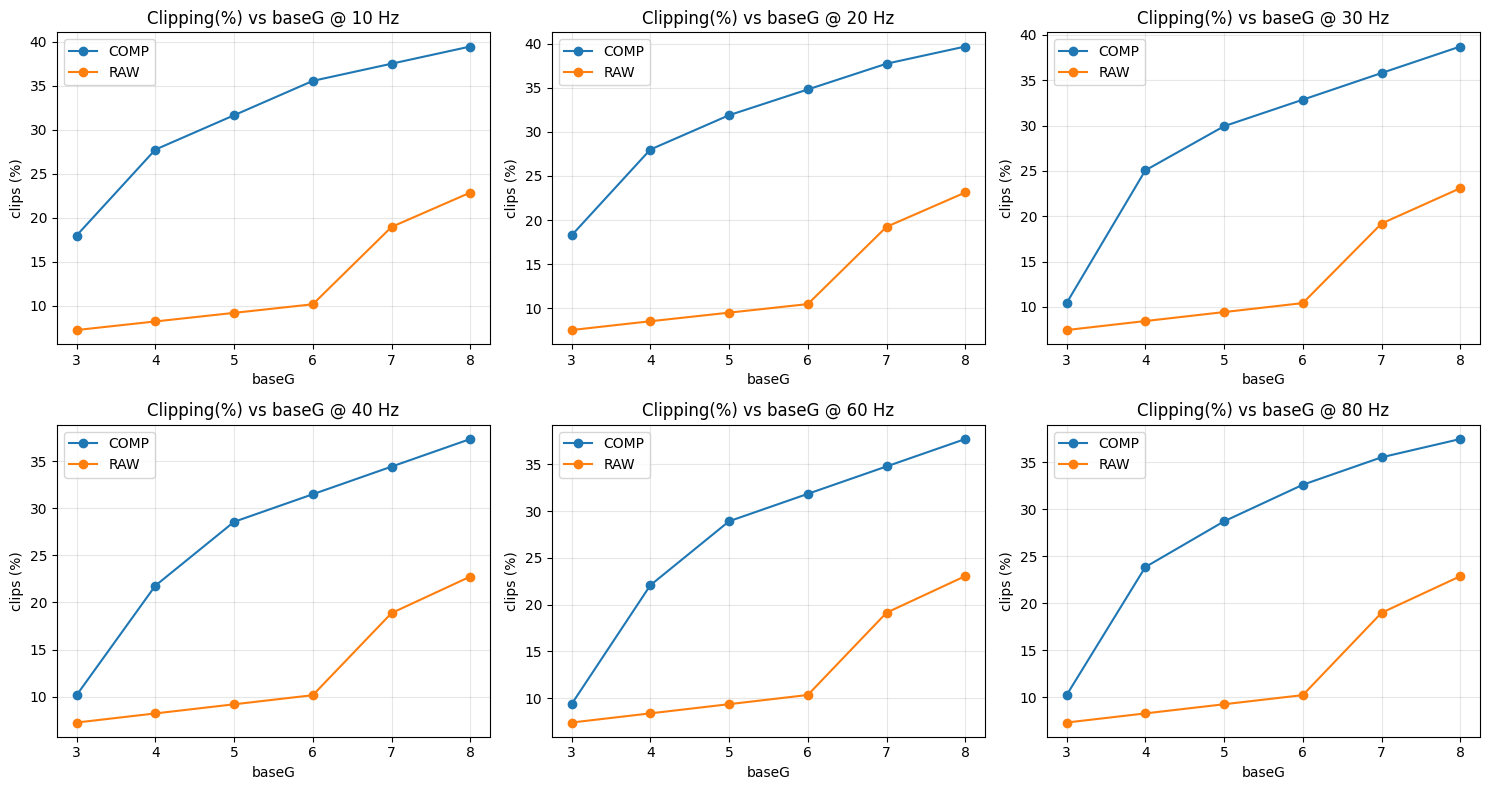

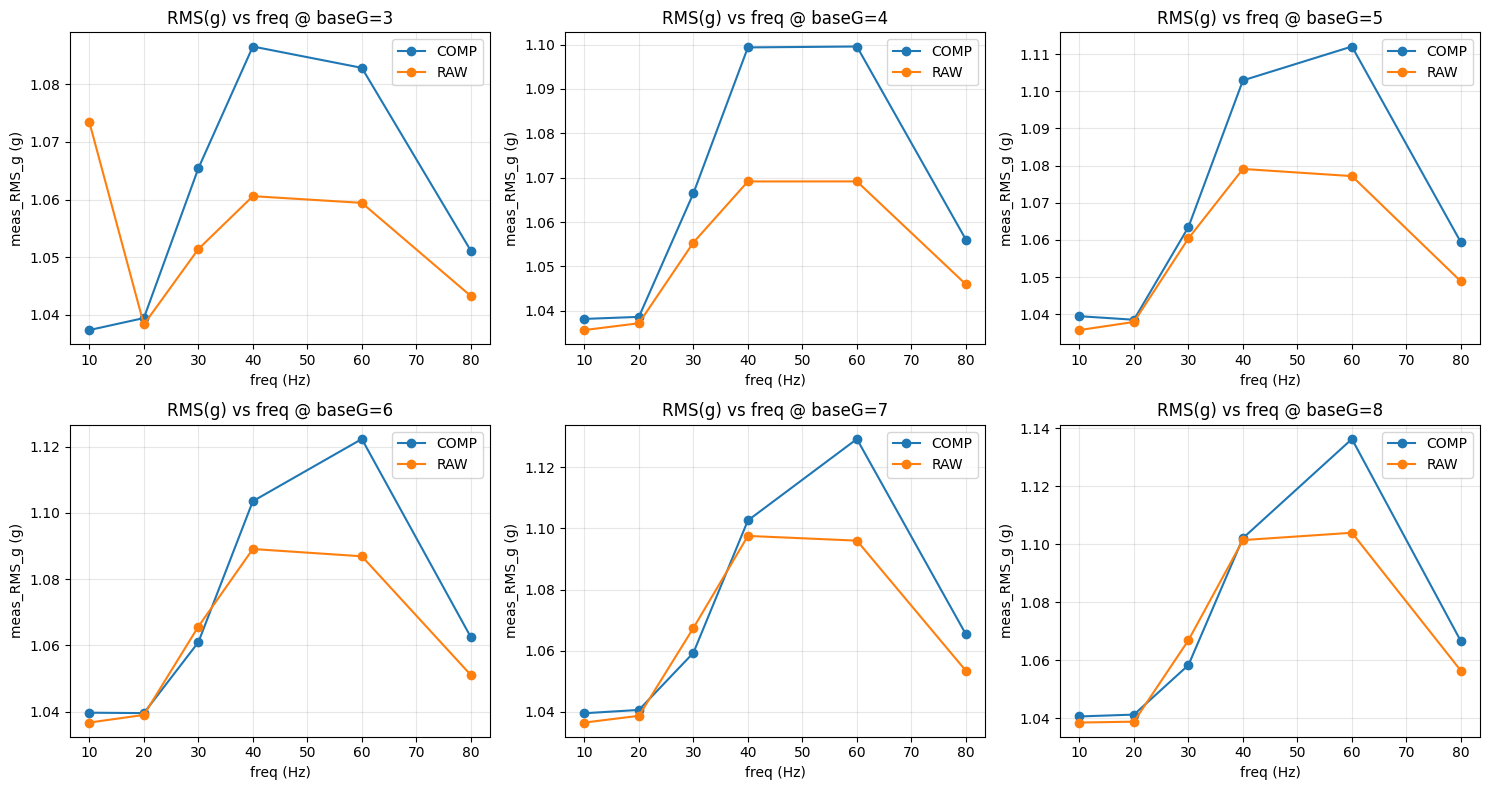

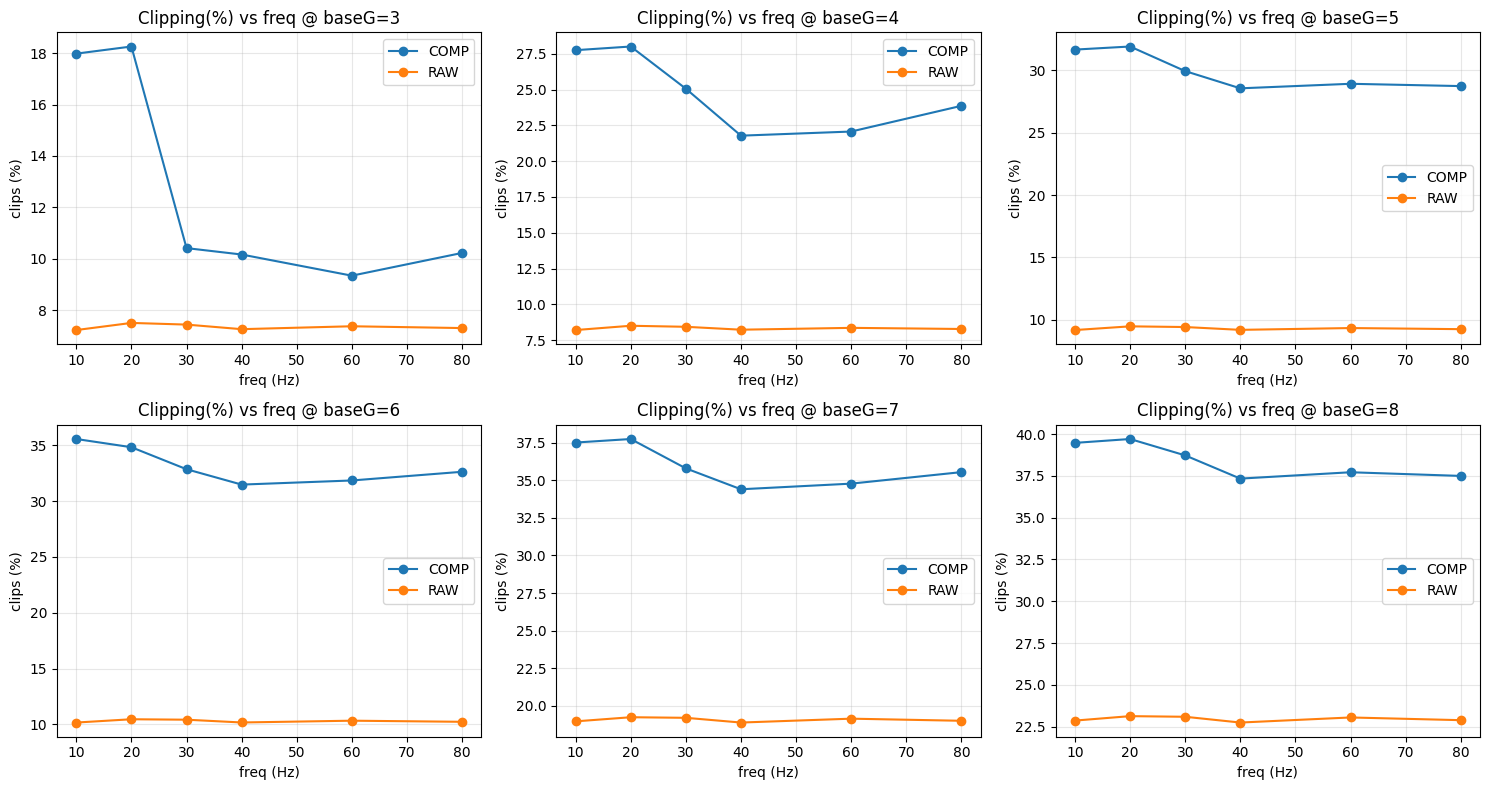

In [57]:
# 2) 부동소수 비교 회피용으로 groupby 사용 (필터 == 대신)
freq_groups = list(df.groupby("freqHz"))
if not freq_groups:
    print("⚠️ freq grouping is empty")
else:
    cols = 3
    rows_ = math.ceil(len(freq_groups)/cols)

    # (A) 주파수별: RMS vs baseG
    fig, axes = plt.subplots(rows_, cols, figsize=(15, 4*rows_), squeeze=False)
    for i,(f, subf) in enumerate(freq_groups):
        ax = axes[i//cols][i%cols]
        for md, subm in subf.groupby("mode"):
            subm = subm.sort_values("baseG")
            ax.plot(subm["baseG"].values, subm["meas_RMS_g"].values, marker='o', label=md)
        ax.set_title(f"RMS(g) vs baseG @ {int(round(f))} Hz")
        ax.set_xlabel("baseG"); ax.set_ylabel("meas_RMS_g (g)")
        ax.grid(True, alpha=0.3); ax.legend()
    for j in range(i+1, rows_*cols): axes[j//cols][j%cols].axis('off')
    plt.tight_layout(); plt.show()

    # (B) 주파수별: Clipping% vs baseG
    fig, axes = plt.subplots(rows_, cols, figsize=(15, 4*rows_), squeeze=False)
    for i,(f, subf) in enumerate(freq_groups):
        ax = axes[i//cols][i%cols]
        for md, subm in subf.groupby("mode"):
            subm = subm.sort_values("baseG")
            ax.plot(subm["baseG"].values, subm["clips_pct"].values, marker='o', label=md)
        ax.set_title(f"Clipping(%) vs baseG @ {int(round(f))} Hz")
        ax.set_xlabel("baseG"); ax.set_ylabel("clips (%)")
        ax.grid(True, alpha=0.3); ax.legend()
    for j in range(i+1, rows_*cols): axes[j//cols][j%cols].axis('off')
    plt.tight_layout(); plt.show()


    #(C) baseG별: freq vs RMS
    bg_groups = list(df.groupby("baseG"))
    if bg_groups:
        cols = 3
        rows_ = math.ceil(len(bg_groups)/cols)
        fig, axes = plt.subplots(rows_, cols, figsize=(15, 4*rows_), squeeze=False)

        for i, (g, subg) in enumerate(bg_groups):
            ax = axes[i//cols][i%cols]
            for md, subm in subg.groupby("mode"):
                subm = subm.sort_values("freqHz")
                ax.plot(subm["freqHz"].values, subm["meas_RMS_g"].values, marker='o', label=md)
            ax.set_title(f"RMS(g) vs freq @ baseG={g:g}")
            ax.set_xlabel("freq (Hz)")
            ax.set_ylabel("meas_RMS_g (g)")
            ax.grid(True, alpha=0.3)
            ax.legend()

        # 남는 서브플롯 비우기
        for j in range(i+1, rows_*cols):
            axes[j//cols][j%cols].axis('off')

        plt.tight_layout()
        plt.show()

        # (옵션) 3-추가) baseG별: freq vs Clipping(%)
    if bg_groups:
        cols = 3
        rows_ = math.ceil(len(bg_groups)/cols)
        fig, axes = plt.subplots(rows_, cols, figsize=(15, 4*rows_), squeeze=False)

        for i, (g, subg) in enumerate(bg_groups):
            ax = axes[i//cols][i%cols]
            for md, subm in subg.groupby("mode"):
                subm = subm.sort_values("freqHz")
                ax.plot(subm["freqHz"].values, subm["clips_pct"].values, marker='o', label=md)
            ax.set_title(f"Clipping(%) vs freq @ baseG={g:g}")
            ax.set_xlabel("freq (Hz)")
            ax.set_ylabel("clips (%)")
            ax.grid(True, alpha=0.3)
            ax.legend()

        for j in range(i+1, rows_*cols):
            axes[j//cols][j%cols].axis('off')

        plt.tight_layout()
        plt.show()


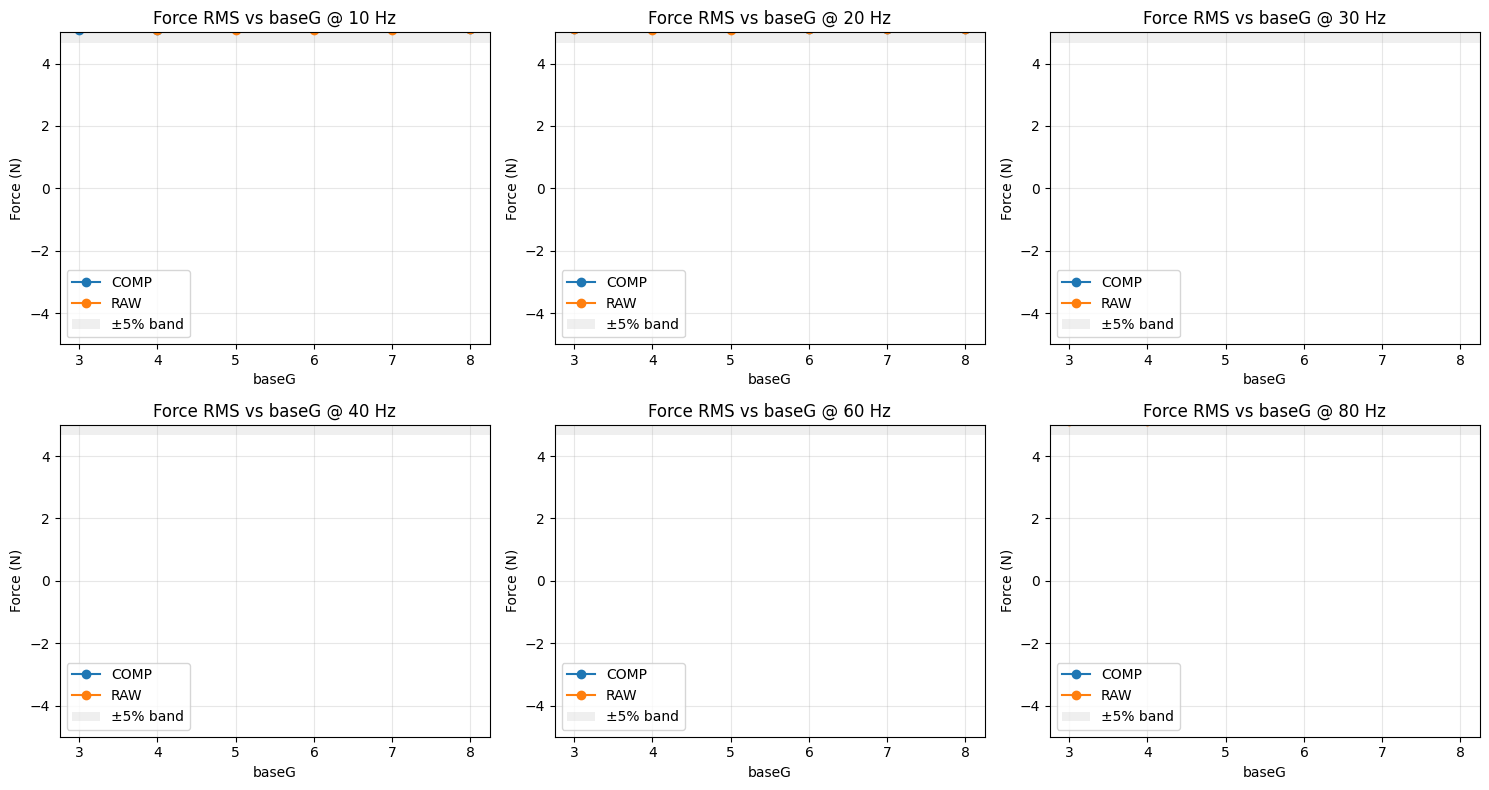

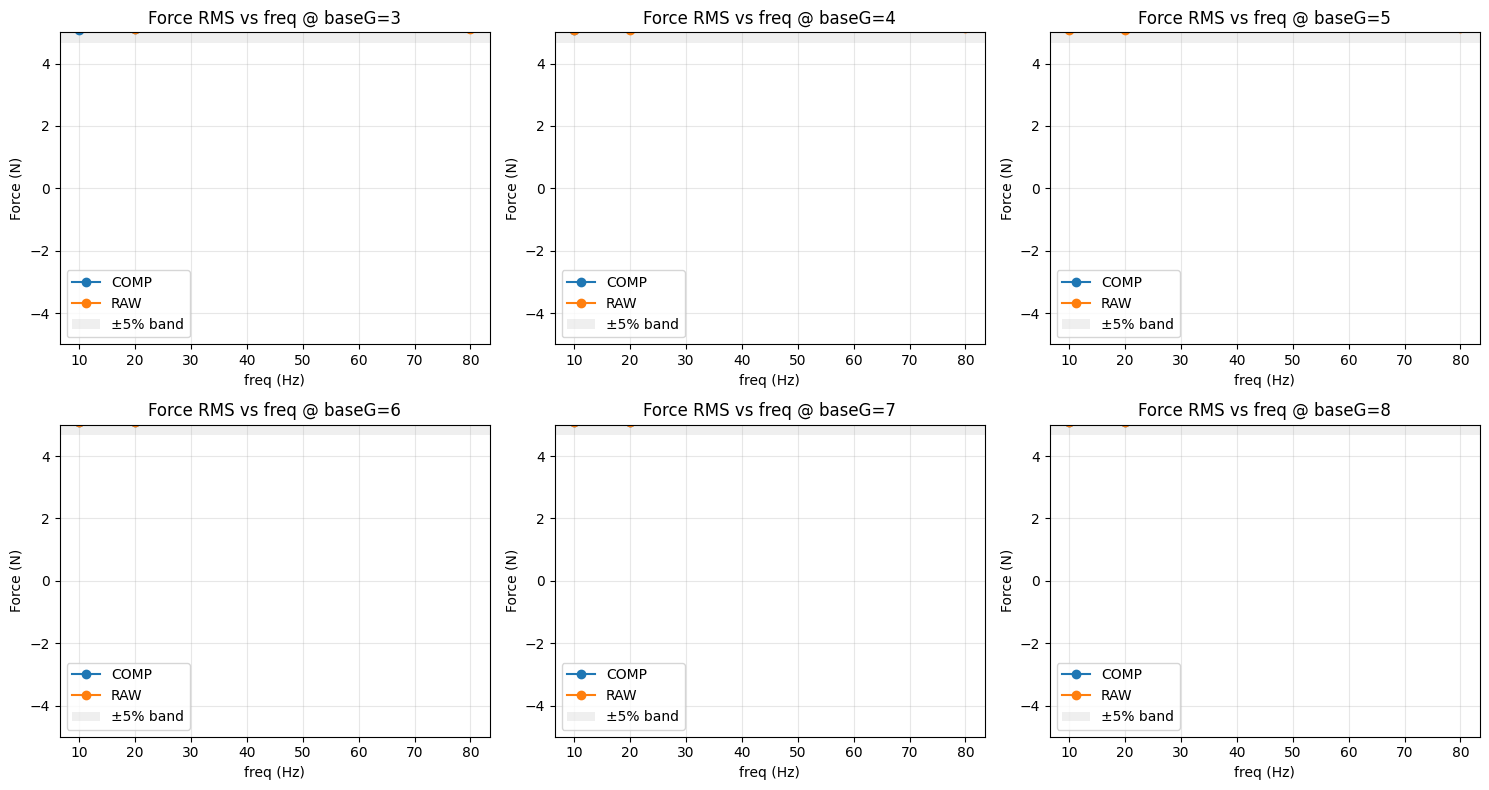


=== Within ±5% band ratio by (mode, freqHz) [%] ===
mode     COMP    RAW
freqHz              
10.0    100.0   83.3
20.0    100.0  100.0
30.0      0.0    0.0
40.0      0.0    0.0
60.0      0.0    0.0
80.0      0.0   50.0

=== Within ±5% band ratio by (mode, baseG) [%] ===
mode   COMP   RAW
baseG            
3.0    33.3  33.3
4.0    33.3  50.0
5.0    33.3  50.0
6.0    33.3  33.3
7.0    33.3  33.3
8.0    33.3  33.3


In [60]:
# =========================
# (추가) Force[N] 축 시각화 + ±5% 밴드 + 요약지표
# =========================

# --- 설정: 시스템 유효 질량(kg)만 상황에 맞게 조정하세요 ---
m_eff = 0.50        # 예: 0.50 kg
g0    = 9.80665     # 표준 중력가속도 [m/s^2]

def g_to_N(g_val):
    return g_val * g0 * m_eff

def apply_force_axis(ax, ylim_N=5.0):
    ax.set_ylabel("Force (N)")
    ax.set_ylim(-ylim_N, ylim_N)
    ax.grid(True, alpha=0.3)

# 목표 RMS를 1.00 g로 가정하고 ±5% 밴드 표시
target_g = 1.00
target_N = g_to_N(target_g)
tol = 0.05  # ±5%
band_low_N  = target_N * (1 - tol)
band_high_N = target_N * (1 + tol)

def add_tolerance_band(ax):
    ax.axhspan(band_low_N, band_high_N, color='gray', alpha=0.12, linewidth=0, label="±5% band")

# ========== (D) 주파수별: Force RMS vs baseG (RAW vs COMP) ==========
freq_groups = list(df.groupby("freqHz"))
if freq_groups:
    cols = 3
    rows_ = math.ceil(len(freq_groups)/cols)
    fig, axes = plt.subplots(rows_, cols, figsize=(15, 4*rows_), squeeze=False)

    for i, (f, subf) in enumerate(freq_groups):
        ax = axes[i//cols][i%cols]
        for md, subm in subf.groupby("mode"):
            subm = subm.sort_values("baseG").copy()
            yN = subm["meas_RMS_g"].apply(g_to_N)
            ax.plot(subm["baseG"].values, yN.values, marker='o', label=md)
        ax.set_title(f"Force RMS vs baseG @ {int(round(f))} Hz")
        ax.set_xlabel("baseG")
        apply_force_axis(ax, ylim_N=5.0)
        add_tolerance_band(ax)
        ax.legend()

    # 남는 서브플롯 비우기
    for j in range(i+1, rows_*cols):
        axes[j//cols][j%cols].axis('off')
    plt.tight_layout(); plt.show()

# ========== (E) baseG별: Force RMS vs freq (RAW vs COMP) ==========
bg_groups = list(df.groupby("baseG"))
if bg_groups:
    cols = 3
    rows_ = math.ceil(len(bg_groups)/cols)
    fig, axes = plt.subplots(rows_, cols, figsize=(15, 4*rows_), squeeze=False)

    for i, (g, subg) in enumerate(bg_groups):
        ax = axes[i//cols][i%cols]
        for md, subm in subg.groupby("mode"):
            subm = subm.sort_values("freqHz").copy()
            yN = subm["meas_RMS_g"].apply(g_to_N)
            ax.plot(subm["freqHz"].values, yN.values, marker='o', label=md)
        ax.set_title(f"Force RMS vs freq @ baseG={g:g}")
        ax.set_xlabel("freq (Hz)")
        apply_force_axis(ax, ylim_N=5.0)
        add_tolerance_band(ax)
        ax.legend()

    for j in range(i+1, rows_*cols):
        axes[j//cols][j%cols].axis('off')
    plt.tight_layout(); plt.show()

# ========== (F) 균일도 요약: ±5% 밴드 내 비율(%) ==========
eval_df = df.copy()
eval_df["within_5pct"] = eval_df["meas_RMS_g"].between(target_g*(1 - tol), target_g*(1 + tol))

print("\n=== Within ±5% band ratio by (mode, freqHz) [%] ===")
summary = (eval_df
           .groupby(["mode","freqHz"])["within_5pct"]
           .mean()
           .mul(100)
           .round(1))
print(summary.unstack(0).fillna(0))  # 열: mode(RAW/COMP)

print("\n=== Within ±5% band ratio by (mode, baseG) [%] ===")
summary2 = (eval_df
            .groupby(["mode","baseG"])["within_5pct"]
            .mean()
            .mul(100)
            .round(1))
print(summary2.unstack(0).fillna(0))
